#**Statistical Analysis of Relationships**

###Sessions vs Sales per Date

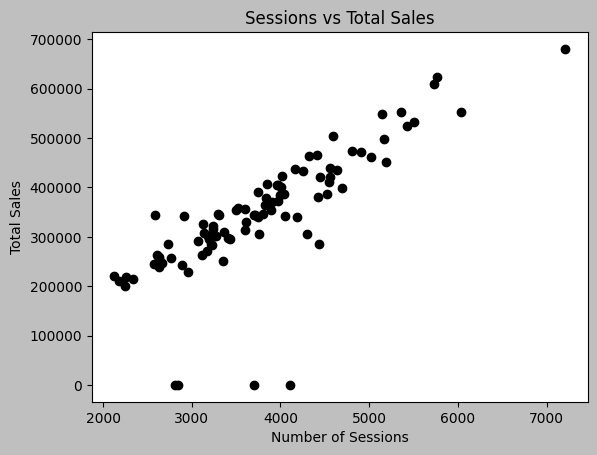

Pearson correlation coefficient: 0.7911
P-value: 0.0
Statistically significant correlation (p < 0.05)


In [ ]:

df['date'] = pd.to_datetime(df['date'])
df['price'] = pd.to_numeric(df['price'], errors='coerce')


daily_stats = df.groupby('date').agg(
    sessions=('ga_session_id', 'nunique'),
    total_sales=('price', 'sum')
).reset_index()


plt.figure()
plt.scatter(daily_stats['sessions'], daily_stats['total_sales'])
plt.title("Sessions vs Total Sales")
plt.xlabel("Number of Sessions")
plt.ylabel("Total Sales")
plt.show()



corr_coef, p_value = pearsonr(daily_stats['sessions'], daily_stats['total_sales'])

print("Pearson correlation coefficient:", round(corr_coef, 4))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("Statistically significant correlation (p < 0.05)")
else:
    print("Correlation is not statistically significant")



###Correlation Between Top-3 Continents

In [ ]:
top3_continents = (
    df.groupby('continent')['price']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

continent_daily = (
    df[df['continent'].isin(top3_continents)]
    .groupby(['date','continent'])['price']
    .sum()
    .unstack()
)


continent_corr = continent_daily.corr()
print("Correlation matrix between continents:")
print(continent_corr)


for c1, c2 in combinations(top3_continents, 2):
    valid_data = continent_daily[[c1, c2]].dropna()
    corr, p = pearsonr(valid_data[c1], valid_data[c2])
    print(f"{c1} vs {c2}: corr={round(corr,4)}, p-value={round(p,6)}")


Correlation matrix between continents:
continent  Americas      Asia    Europe
continent                              
Americas   1.000000  0.792025  0.770586
Asia       0.792025  1.000000  0.768427
Europe     0.770586  0.768427  1.000000
Americas vs Asia: corr=0.792, p-value=0.0
Americas vs Europe: corr=0.7706, p-value=0.0
Asia vs Europe: corr=0.7684, p-value=0.0


###Correlation Between Traffic Channels

In [ ]:
channel_daily = (
    df.groupby(['date','traffic_channel'])['price']
    .sum()
    .unstack()
)

channel_corr = channel_daily.corr()
print("Correlation matrix between traffic channels:")
print(channel_corr)

for ch1, ch2 in combinations(channel_daily.columns, 2):
    valid_data = channel_daily[[ch1, ch2]].dropna()
    if len(valid_data) > 2:
        corr, p = pearsonr(valid_data[ch1], valid_data[ch2])
        print(f"{ch1} vs {ch2}: corr={round(corr,4)}, p-value={round(p,6)}")


Correlation matrix between traffic channels:
traffic_channel    Direct  Organic Search  Paid Search  Social Search  \
traffic_channel                                                         
Direct           1.000000        0.837833     0.814072       0.604060   
Organic Search   0.837833        1.000000     0.870086       0.583117   
Paid Search      0.814072        0.870086     1.000000       0.596428   
Social Search    0.604060        0.583117     0.596428       1.000000   
Undefined        0.517505        0.526068     0.521961       0.455126   

traffic_channel  Undefined  
traffic_channel             
Direct            0.517505  
Organic Search    0.526068  
Paid Search       0.521961  
Social Search     0.455126  
Undefined         1.000000  
Direct vs Organic Search: corr=0.8378, p-value=0.0
Direct vs Paid Search: corr=0.8141, p-value=0.0
Direct vs Social Search: corr=0.6041, p-value=0.0
Direct vs Undefined: corr=0.5175, p-value=0.0
Organic Search vs Paid Search: corr=0.8701, p

###Correlation Between Top-5 Product Categories

In [ ]:
top5_categories = (
    df.groupby('category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

category_daily = (
    df[df['category'].isin(top5_categories)]
    .groupby(['date','category'])['price']
    .sum()
    .unstack()
)


category_corr = category_daily.corr()
print("Correlation matrix between top-5 categories:")
print(category_corr)


for cat1, cat2 in combinations(top5_categories, 2):
    valid_data = category_daily[[cat1, cat2]].dropna()
    if len(valid_data) > 2:
        corr, p = pearsonr(valid_data[cat1], valid_data[cat2])
        print(f"{cat1} vs {cat2}: corr={round(corr,4)}, p-value={round(p,6)}")


Correlation matrix between top-5 categories:
category                        Beds  Bookcases & shelving units  \
category                                                           
Beds                        1.000000                    0.592913   
Bookcases & shelving units  0.592913                    1.000000   
Cabinets & cupboards        0.514609                    0.539428   
Chairs                      0.554500                    0.637090   
Sofas & armchairs           0.535378                    0.666194   

category                    Cabinets & cupboards    Chairs  Sofas & armchairs  
category                                                                       
Beds                                    0.514609  0.554500           0.535378  
Bookcases & shelving units              0.539428  0.637090           0.666194  
Cabinets & cupboards                    1.000000  0.572870           0.657563  
Chairs                                  0.572870  1.000000           0.578248 

###Overall Statistical Conclusions

The correlation analysis shows that all examined relationships are statistically significant (p-value < 0.05).

**Sessions and total sales** demonstrate a strong positive correlation (r ≈ 0.79), confirming that revenue growth is strongly driven by traffic volume. An increase in sessions systematically leads to higher sales.

**Sales across continents (Americas, Asia, Europe)** also show strong positive correlations (r ≈ 0.77–0.79). This indicates synchronized global sales dynamics, likely influenced by seasonality, marketing campaigns, or macroeconomic factors.

**Traffic channels** exhibit strong interrelationships (up to r ≈ 0.87 between Organic and Paid). This suggests a multichannel effect and overlapping audiences. Channels operate in an integrated rather than isolated manner.

**Top-5 product categories** display moderate positive correlations (r ≈ 0.51–0.67). Categories tend to grow together, which may indicate cross-selling behavior or bundled purchasing patterns.


**Overall conclusion:**
Sales are strongly dependent on traffic, regions demonstrate synchronized dynamics, marketing channels interact closely, and product categories grow in parallel rather than competing aggressively. The business operates as an interconnected system.